In [11]:
import polars as pl
import pandas as pd
from typing import Dict, Union, Optional, List, Any
from mars.utils.logger import logger

try:
    from IPython.display import display, HTML
except ImportError:
    display = None

class MarsEvaluationReport:
    """
    [MarsEvaluationReport] 特征效能评估报告容器。
    """

    def __init__(
        self, 
        summary_table: Union[pl.DataFrame, pd.DataFrame],
        trend_tables: Dict[str, Union[pl.DataFrame, pd.DataFrame]],
        detail_table: Union[pl.DataFrame, pd.DataFrame] 
    ) -> None:
        self.summary_table = self._to_pd(summary_table)
        self.trend_tables = {k: self._to_pd(v) for k, v in trend_tables.items()}
        self.detail_table = self._to_pd(detail_table)

    def get_data(self):
        """获取所有原始数据"""
        return self.summary_table, self.trend_tables, self.detail_table

    def _to_pd(self, df: Any) -> pd.DataFrame:
        if isinstance(df, pl.DataFrame):
            return df.to_pandas()
        return df

    def _repr_html_(self) -> str:
        """Jupyter Notebook 仪表盘视图"""
        n_feats = len(self.summary_table)
        
        # 简单统计报警数
        high_risk_psi = 0
        if "PSI_max" in self.summary_table.columns:
            high_risk_psi = sum(self.summary_table["PSI_max"] > 0.25)

        lines = []
        lines.append('<code>.show_summary()</code> 👈 <b>Feature Ranking (PSI/AUC)</b>')
        
        trend_links = [f"<code>.show_trend('{k}')</code>" for k in self.trend_tables.keys()]
        lines.append(f'Trend Heatmaps: {", ".join(trend_links)}')
        lines.append('<code>.write_excel()</code> Export monitoring report')

        return f"""
        <div style="border-left: 5px solid #8e44ad; background-color: #f4f6f7; padding: 15px; border-radius: 0 5px 5px 0;">
            <h3 style="margin:0 0 10px 0; color:#2c3e50;">📉 Mars Feature Evaluation</h3>
            <div style="display: flex; gap: 30px; margin-bottom: 10px; color: #555;">
                <div><strong>🏷️ Features:</strong> {n_feats}</div>
                <div><strong>🚨 High PSI (>0.25):</strong> <span style="color: {'red' if high_risk_psi > 0 else 'green'}">{high_risk_psi}</span></div>
            </div>
            <div style="font-size:0.9em; line-height:1.8; color:#7f8c8d; border-top: 1px solid #e0e0e0; padding-top: 8px;">
                { "<br>".join(lines) }
            </div>
        </div>
        """

    def show_summary(self) -> "pd.io.formats.style.Styler":
        """
        展示特征汇总评分表。
        """
        df = self.summary_table
        styler = df.style.set_caption("<b>Feature Performance Summary</b>").hide(axis="index")

        # 1. PSI: 低好高坏 (RdYlGn_r)
        if "PSI_max" in df.columns:
            styler = styler.background_gradient(
                cmap="RdYlGn_r", subset=["PSI_max", "PSI_avg"], vmin=0, vmax=0.5
            )
        
        # 2. AUC/KS: 高好低坏 (RdYlGn)
        good_metrics = [c for c in ["AUC_avg", "AUC_min", "KS_max"] if c in df.columns]
        if good_metrics:
            styler = styler.background_gradient(
                cmap="RdYlGn", subset=good_metrics, vmin=0.5, vmax=0.8
            )

        # 3. 稳定性: CV (低好高坏)
        if "CV_AUC" in df.columns:
            styler = styler.bar(subset=["CV_AUC"], color='#ff9999', vmin=0, vmax=0.2)

        # 4. 格式化
        return styler.format("{:.4f}", subset=df.select_dtypes("number").columns)

    def show_trend(self, metric: str) -> "pd.io.formats.style.Styler":
        """
        展示指标的时间趋势热力图。
        """
        if metric not in self.trend_tables:
            raise ValueError(f"Unknown metric: {metric}. Options: {list(self.trend_tables.keys())}")
        
        df = self.trend_tables[metric]
        
        # [修改点 1]：Total 改为大写，与 Evaluator 生成的列名一致
        meta_cols = ["feature", "dtype", "Total"] 
        time_cols = [c for c in df.columns if c not in meta_cols]

        styler = df.style.set_caption(f"<b>Trend Analysis: {metric.upper()}</b>").hide(axis="index")
        
        # 设置 Feature 列左对齐并固定
        styler = styler.set_properties(subset=["feature"], **{'text-align': 'left', 'font-weight': 'bold'})

        # 根据指标类型选择配色
        if metric == "psi":
            styler = styler.background_gradient(
                cmap="RdYlGn_r", subset=time_cols, vmin=0, vmax=0.25, axis=None
            )
        elif metric in ["auc", "ks", "iv"]:
            styler = styler.background_gradient(
                cmap="RdYlGn", subset=time_cols, axis=None
            )
        elif metric == "bad_rate":
            styler = styler.background_gradient(
                cmap="Blues", subset=time_cols, axis=None
            )

        # [修改点 2]：Total 改为大写
        # 只有当 Total 列确实存在时才进行格式化，防止有些特殊的 metric 没有 Total
        format_cols = time_cols + (["Total"] if "Total" in df.columns else [])
        return styler.format("{:.4f}", subset=format_cols)

    def write_excel(self, path: str = "mars_evaluation_report.xlsx") -> None:
        """
        导出为带有条件格式的 Excel 监控报表。
        """
        logger.info(f"📊 Exporting evaluation report to: {path}...")
        try:
            with pd.ExcelWriter(path, engine="xlsxwriter") as writer:
                # 1. Summary Sheet
                self.show_summary().to_excel(writer, sheet_name="Summary", index=False)
                
                # 2. Trend Sheets
                for metric, df in self.trend_tables.items():
                    sheet_name = f"Trend_{metric.upper()}"
                    df.to_excel(writer, sheet_name=sheet_name, index=False)
                    
                    workbook = writer.book
                    worksheet = writer.sheets[sheet_name]
                    
                    first_row = 1
                    last_row = len(df)
                    meta_cols = ["feature", "dtype"]
                    first_col = len([c for c in df.columns if c in meta_cols])
                    last_col = len(df.columns) - 1

                    if metric == "psi":
                        worksheet.conditional_format(first_row, first_col, last_row, last_col, {
                            'type': '3_color_scale',
                            'min_type': 'num', 'min_value': 0,    'min_color': '#63BE7B',
                            'mid_type': 'num', 'mid_value': 0.1,  'mid_color': '#FFEB84',
                            'max_type': 'num', 'max_value': 0.25, 'max_color': '#F8696B'
                        })
                    elif metric in ["auc", "ks"]:
                        worksheet.conditional_format(first_row, first_col, last_row, last_col, {
                            'type': '2_color_scale',
                            'min_color': '#F8696B',
                            'max_color': '#63BE7B'
                        })
                    
                    worksheet.autofit()
                    
            logger.info("✅ Export successful.")
        except Exception as e:
            logger.error(f"❌ Export failed: {e}")

In [12]:
import polars as pl
import numpy as np
from typing import List, Optional, Dict, Union, Any, Tuple

from mars.core.base import MarsBaseEstimator
from mars.feature.binner import MarsBinnerBase, MarsNativeBinner
# from mars.analysis.evaluation_report import MarsEvaluationReport
from mars.utils.logger import logger
from mars.utils.decorators import time_it
from mars.utils.date import MarsDate

class MarsFeatureEvaluator(MarsBaseEstimator):
    """
    [MarsFeatureEvaluator] 特征效能与稳定性评估引擎 (Production Ready)。

    该类用于在分箱完成后，评估特征在时间（Time）或客群（Segment）维度上的
    表现趋势。

    Key Features
    ------------
    1. **基准自动对齐**: 支持传入 OOT/Train 集作为基准，或自动选取时间轴最早的切片作为基准。
    2. **严格排序逻辑**: 计算 AUC/KS 时，严格基于全局 WOE 值排序，有效监控特征逻辑反转。
    3. **动态 IV 计算**: IV 计算基于当月实际分布，客观反映当前区分能力。
    4. **样本权重支持**: [New] 全面支持带权重的样本计算 (PSI/IV/AUC/Lift/BadRate)。
    5. **单调性检测**: [New] 自动计算分箱单调性 (Spearman Correlation)，辅助判断业务逻辑。
    6. **性能优化**: [New] 优化了 Mapping 映射逻辑，避免大循环扫描 DataFrame。

    Example
    -------
    >>> evaluator = MarsFeatureEvaluator(target_col="bad")
    >>> # 自动拟合分箱并评估月度趋势 (支持权重)
    >>> report = evaluator.evaluate(df, features=["age"], profile_by="month", weights_col="weight")
    >>> report.show_trend("auc")
    """

    def __init__(
        self, 
        target_col: str = "target",
        binner: Optional[MarsBinnerBase] = None,
        **binner_kwargs
    ) -> None:
        """
        Parameters
        ----------
        target_col : str
            目标变量列名 (0/1)。
        binner : MarsBinnerBase, optional
            已拟合的分箱器实例。如果为 None，evaluate 时会在内部自动拟合一个。
        **binner_kwargs : dict
            当 binner 为 None 时，传递给默认 MarsNativeBinner 的参数。
        """
        super().__init__()
        self.target_col = target_col
        self.binner = binner
        self.binner_kwargs = binner_kwargs

    @time_it
    def evaluate(
        self,
        df: pl.DataFrame,
        features: Optional[List[str]] = None,
        profile_by: Optional[str] = None,
        dt_col: Optional[str] = None,
        benchmark_df: Optional[pl.DataFrame] = None,
        weights_col: Optional[str] = None # [新增参数] 样本权重列
    ) -> MarsEvaluationReport:
        """
        执行特征效能评估。

        Parameters
        ----------
        df : pl.DataFrame
            待评估的数据集（通常是全量样本或 OOT 样本）。
        features : List[str], optional
            需要评估的特征列表。None 则自动识别。
        profile_by : str
            分组列名 (如 'month', 'vintage')。
        dt_col : str, optional
            日期列。如果 profile_by 是 'month'/'day' 等时间粒度，会自动基于此列聚合。
        benchmark_df : pl.DataFrame, optional
            基准数据集。用于计算 PSI 的 Expected 分布。
        weights_col : str, optional
            样本权重列名。若提供，所有指标均基于权重计算。

        Returns
        -------
        MarsEvaluationReport
            包含 Summary, Trend Tables 和 Detail Table 的报告对象。
        """
        # [鲁棒性检查]：防御单一类别 Target (防止 AUC/KS 报错)
        n_unique = df.select(pl.col(self.target_col).n_unique()).item()
        if n_unique < 2:
            logger.warning(f"⚠️ Target column '{self.target_col}' has less than 2 unique values. Metrics (AUC/KS) may be invalid or NaN.")

        # 1. 上下文准备 (处理日期聚合)
        working_df, group_col = self._prepare_context(df, profile_by, dt_col)
        
        # 2. 确定特征范围 (排除非特征列)
        exclude_cols = [self.target_col, group_col]
        if weights_col:
            exclude_cols.append(weights_col)
            
        target_features = features if features else [
            c for c in working_df.columns if c not in exclude_cols
        ]

        # 3. 分箱器准备 (Fit or Use)
        if self.binner is None:
            logger.info("⚙️ No binner provided. Fitting MarsNativeBinner internally...")
            # 默认使用 Quantile 分箱，速度快且稳健
            self.binner = MarsNativeBinner(features=target_features, **self.binner_kwargs)
            self.binner.fit(working_df, working_df.get_column(self.target_col))
        
        # 4. 转换数据 (Get Indices)
        logger.info("🔄 Transforming features to bin indices...")
        df_binned = self.binner.transform(working_df, return_type="index")
        
        # 5. [核心优化] 确保 WOE 存在 (用于排序)
        # 传入权重列，确保如果需要补全 WOE，计算逻辑也是加权的
        self._ensure_woe_info(df_binned, target_features, self.target_col, weights_col)

        # 6. 计算基准分布 (Expected Distribution for PSI)
        expected_dist = self._get_benchmark_dist(
            working_df, benchmark_df, group_col, target_features, weights_col
        )

        # 7. 核心计算 (分两步走：分组 + 全量)
        
        # --- 7.1 计算分组指标 (Group Level) ---
        stats_groups = self._calc_group_metrics(
            df_binned, expected_dist, group_col, target_features, weights_col
        )
        # 为了能和 Total 合并，先把分组列转为 String
        stats_groups = stats_groups.with_columns(pl.col(group_col).cast(pl.String))

        # --- 7.2 计算全量指标 (Total Level) ---
        # 技巧：构造一个临时的常量列 "Total"，当作 group_col 传进去
        total_col_name = "_mars_total_placeholder_"
        df_binned_total = df_binned.with_columns(pl.lit("Total").alias(total_col_name))
        
        stats_total = self._calc_group_metrics(
            df_binned_total, expected_dist, total_col_name, target_features, weights_col
        )
        # 将临时列名改回真正的 group_col 名字，以便 concat
        stats_total = stats_total.rename({total_col_name: group_col})

        # --- 7.3 合并结果 ---
        stats_long = pl.concat([stats_total, stats_groups])

        # 8. 格式化输出 (Reshape to Wide Tables & Detail Table)
        return self._format_report(stats_long, group_col)

    def _prepare_context(self, df: pl.DataFrame, profile_by: str, dt_col: str) -> Tuple[pl.DataFrame, str]:
        """[Internal] 处理日期列自动聚合逻辑"""
        if dt_col and profile_by in ["day", "week", "month"]:
            if profile_by == "month":
                date_expr = MarsDate.dt2month(dt_col)
            elif profile_by == "week":
                date_expr = MarsDate.dt2week(dt_col)
            else:
                date_expr = MarsDate.dt2day(dt_col)
            
            temp_group = f"_mars_auto_{profile_by}"
            return df.with_columns(date_expr.alias(temp_group)), temp_group
        
        return df, profile_by

    def _ensure_woe_info(self, df_binned: pl.DataFrame, features: List[str], y_col: str, weights_col: Optional[str] = None):
        """
        [Helper] 检查并补全 Binner 中的 WOE 信息。
        KS 和 AUC 必须依赖 WOE 排序。如果 Binner 是空的或没有 WOE，
        我们基于当前传入的 df_binned (全量) 计算一份 Global WOE。
        """
        missing_woe_feats = []
        for f in features:
            if f not in self.binner.bin_woes_ or not self.binner.bin_woes_[f]:
                missing_woe_feats.append(f)
        
        if not missing_woe_feats:
            return

        logger.info(f"⚡ Calculating missing WOEs for {len(missing_woe_feats)} features to ensure correct AUC/KS sorting...")
        
        # 批量计算 WOE
        bin_cols = [f"{f}_bin" for f in missing_woe_feats]
        
        # Unpivot -> GroupBy -> Calc WOE
        # 1. 全局 Bad/Good (支持权重)
        if weights_col:
            total_bad = (df_binned.get_column(y_col) * df_binned.get_column(weights_col)).sum()
            total_count = df_binned.get_column(weights_col).sum()
        else:
            total_bad = df_binned.get_column(y_col).sum()
            total_count = df_binned.height
            
        total_good = total_count - total_bad
        epsilon = 1e-6 

        # 动态聚合表达式
        if weights_col:
            agg_n = pl.col(weights_col).sum().alias("n")
            agg_b = (pl.col(y_col) * pl.col(weights_col)).sum().alias("b")
        else:
            agg_n = pl.len().alias("n")
            agg_b = pl.col(y_col).sum().alias("b")

        stats = (
            df_binned.select(bin_cols + [y_col] + ([weights_col] if weights_col else []))
            .unpivot(
                index=[y_col] + ([weights_col] if weights_col else []), 
                on=bin_cols, 
                variable_name="feature_bin", 
                value_name="bin_index"
            )
            .with_columns(pl.col("feature_bin").str.replace("_bin", "").alias("feature"))
            .group_by(["feature", "bin_index"])
            .agg([agg_n, agg_b])
            .with_columns([
                (pl.col("n") - pl.col("b")).alias("g")
            ])
            .with_columns([
                (((pl.col("b") + epsilon) / (total_bad + epsilon)) / 
                 ((pl.col("g") + epsilon) / (total_good + epsilon))).log().alias("woe")
            ])
        )

        # 结果写回 self.binner.bin_woes_
        stats_dict = stats.partition_by("feature", as_dict=True)
        
        for (feat_tuple), sub_df in stats_dict.items():
            feat = feat_tuple[0] 
            woe_map = dict(zip(sub_df["bin_index"].to_list(), sub_df["woe"].to_list()))
            self.binner.bin_woes_[feat] = woe_map

    def _get_benchmark_dist(
        self, 
        df: pl.DataFrame, 
        bench_df: Optional[pl.DataFrame], 
        group_col: str,
        features: List[str],
        weights_col: Optional[str] = None
    ) -> pl.DataFrame:
        """[Internal] 计算基准分布 (Expected Probability)，支持权重。"""
        # 确定基准数据
        if bench_df is not None:
            target_bench = bench_df
        else:
            min_group = df.select(pl.col(group_col).min()).item()
            logger.info(f"📅 Baseline not provided. Using earliest group '{min_group}' as baseline.")
            target_bench = df.filter(pl.col(group_col) == min_group)

        # Transform 基准数据
        bench_binned = self.binner.transform(target_bench, return_type="index")
        bin_cols = [f"{f}_bin" for f in features]
        
        # 支持权重计算 Expected Count
        if weights_col:
            agg_expr = pl.col(weights_col).sum().alias("N_E")
        else:
            agg_expr = pl.len().alias("N_E")

        return (
            bench_binned.select(bin_cols + ([weights_col] if weights_col else []))
            .unpivot(
                index=[weights_col] if weights_col else [],
                variable_name="feature_bin", 
                value_name="bin_index"
            )
            .with_columns(pl.col("feature_bin").str.replace("_bin", "").alias("feature"))
            .group_by(["feature", "bin_index"])
            .agg(agg_expr) 
            .with_columns(
                (pl.col("N_E") / pl.col("N_E").sum().over("feature")).alias("prob_E")
            )
            .select(["feature", "bin_index", "prob_E"])
        )

    def _calc_group_metrics(
        self, 
        df_binned: pl.DataFrame, 
        expected_dist: pl.DataFrame,
        group_col: str,
        features: List[str],
        weights_col: Optional[str] = None
    ) -> pl.DataFrame:
        """[Core] 核心计算引擎：计算 PSI, IV, KS, AUC, Lift 等分组指标"""
        
        y_col = self.target_col
        bin_cols = [f"{f}_bin" for f in features]
        
        # 0. 定义动态聚合表达式 (支持权重)
        if weights_col:
            # 有权重：N=权重之和, B=权重*Target之和
            agg_exprs = [
                pl.col(weights_col).sum().alias("N_A"),
                (pl.col(y_col) * pl.col(weights_col)).sum().alias("B_A")
            ]
        else:
            # 无权重：N=行数, B=Target之和
            agg_exprs = [
                pl.len().alias("N_A"),
                pl.col(y_col).sum().alias("B_A")
            ]

        # 1. 聚合实际数据 (Actuals)
        logger.info("📊 Aggregating grouped stats...")
        actuals = (
            df_binned.select([group_col, y_col] + bin_cols + ([weights_col] if weights_col else []))
            .unpivot(
                index=[group_col, y_col] + ([weights_col] if weights_col else []), 
                on=bin_cols, 
                variable_name="feature_bin", 
                value_name="bin_index"
            )
            .with_columns(pl.col("feature_bin").str.replace("_bin", "").alias("feature"))
            .group_by([group_col, "feature", "bin_index"])
            .agg(agg_exprs) # <--- 使用动态聚合表达式
            .with_columns((pl.col("N_A") - pl.col("B_A")).alias("G_A")) # Actual Goods
        )

        # 2. 注入 WOE 值 (用于严格排序 - KS/AUC 稳定性监控)
        woe_map_list = []
        for feat, mapping in self.binner.bin_woes_.items():
            if feat in features:
                for idx, val in mapping.items():
                    woe_map_list.append({"feature": feat, "bin_index": idx, "woe": val})
        
        if not woe_map_list:
             raise ValueError("CRITICAL: WOE map is empty even after calculation attempt.")
        
        woe_df = pl.DataFrame(woe_map_list, schema={"feature": pl.String, "bin_index": pl.Int16, "woe": pl.Float64})

        # 3. 宽表关联
        base_df = (
            actuals
            .join(expected_dist, on=["feature", "bin_index"], how="left")
            .join(woe_df, on=["feature", "bin_index"], how="left")
            .with_columns([
                pl.col("N_A").fill_null(0),
                pl.col("B_A").fill_null(0),
                pl.col("G_A").fill_null(0),
                pl.col("prob_E").fill_null(1e-9), 
                pl.col("woe").fill_null(0)        
            ])
        )

        # 4. 向量化指标计算
        epsilon = 1e-9
        
        # 4.1 计算分组级别的 Sum
        base_df = base_df.with_columns([
            pl.col("N_A").sum().over([group_col, "feature"]).alias("Total_N"),
            pl.col("B_A").sum().over([group_col, "feature"]).alias("Total_B"),
            pl.col("G_A").sum().over([group_col, "feature"]).alias("Total_G"),
        ])

        # 4.2 计算分布占比 & 坏账率
        base_df = base_df.with_columns([
            ((pl.col("N_A") + epsilon) / (pl.col("Total_N") + epsilon)).alias("prob_A"),
            (pl.col("B_A") / (pl.col("Total_B") + epsilon)).alias("dist_B"),
            (pl.col("G_A") / (pl.col("Total_G") + epsilon)).alias("dist_G"),
            (pl.col("B_A") / (pl.col("N_A") + epsilon)).alias("bin_bad_rate"),
        ])

        # 4.3 计算衍生指标 (PSI, Lift)
        base_df = base_df.with_columns([
            ((pl.col("prob_A") - pl.col("prob_E")) * (pl.col("prob_A") / pl.col("prob_E")).log()).alias("psi_bin"),
            
            # Lift = BinBadRate / TotalBadRate
            (pl.col("bin_bad_rate") / 
             ((pl.col("Total_B") + epsilon) / (pl.col("Total_N") + epsilon))
            ).alias("lift_bin")  
        ])

        # 4.4 计算需排序指标 (KS, AUC, IV)
        # 关键逻辑：按照固定 WOE 排序，以捕捉特征逻辑反转 (Flip)
        sorted_df = base_df.sort([group_col, "feature", "woe"])

        # 计算累计分布 (CumSum)
        sorted_df = sorted_df.with_columns([
            pl.col("dist_B").cum_sum().over([group_col, "feature"]).alias("cum_dist_B"),
            pl.col("dist_G").cum_sum().over([group_col, "feature"]).alias("cum_dist_G"),
        ])

        sorted_df = sorted_df.with_columns([
            # KS: 累积好坏差值的绝对值最大者
            (pl.col("cum_dist_B") - pl.col("cum_dist_G")).abs().alias("ks_bin"),
            
            # AUC: 梯形法则
            ((pl.col("cum_dist_G") - pl.col("cum_dist_G").shift(1).over([group_col, "feature"]).fill_null(0)) * (pl.col("cum_dist_B") + pl.col("cum_dist_B").shift(1).over([group_col, "feature"]).fill_null(0)) / 2
            ).alias("auc_bin"),

            # IV: 使用当月动态分布计算 (反映当前区分度)
            ((pl.col("dist_G") - pl.col("dist_B")) * ((pl.col("dist_G") + epsilon) / (pl.col("dist_B") + epsilon)).log()).alias("iv_bin")
        ])

        return sorted_df

    def _format_report(self, metrics_df: pl.DataFrame, group_col: str) -> MarsEvaluationReport:
        """
        [Refactored] 格式化输出。
        """
        # --- Step 1: 构建 Mapping DataFrame ---
        mapping_rows = []
        target_feats = set(metrics_df["feature"].unique().to_list())
        
        for feat, mapping in self.binner.bin_mappings_.items():
            if feat in target_feats:
                for idx, label in mapping.items():
                    mapping_rows.append({"feature": feat, "bin_index": idx, "bin_label": label})
        
        if mapping_rows:
            map_df = pl.DataFrame(mapping_rows, schema={
                "feature": pl.String, "bin_index": pl.Int16, "bin_label": pl.String
            })
        else:
            map_df = pl.DataFrame({"feature": [], "bin_index": [], "bin_label": []}, 
                                  schema={"feature": pl.String, "bin_index": pl.Int16, "bin_label": pl.String})

        # --- Step 2: 生成 Detail Table (长表) ---
        detail_table = (
            metrics_df
            .join(map_df, on=["feature", "bin_index"], how="left")
            .with_columns(pl.col("bin_label").fill_null(pl.col("bin_index").cast(pl.Utf8)))
            .select([
                "feature", group_col, "bin_index", "bin_label", 
                "N_A", "B_A", "bin_bad_rate", 
                "lift_bin", 
                "psi_bin", "ks_bin", "auc_bin", "iv_bin",
                "Total_N", "Total_B" 
            ])
            .sort(["feature", group_col, "bin_index"])
        )

        # --- Step 3: 生成 Group Level Stats ---
        group_level_stats = (
            metrics_df.group_by([group_col, "feature"])
            .agg([
                pl.col("psi_bin").sum().alias("psi"),
                pl.col("ks_bin").max().alias("ks"),
                pl.col("auc_bin").sum().alias("auc"),
                pl.col("iv_bin").sum().alias("iv"),
                (pl.col("Total_B").first() / (pl.col("Total_N").first() + 1e-9)).alias("bad_rate")
            ])
            .with_columns(
                pl.when(pl.col("auc") < 0.5).then(1 - pl.col("auc")).otherwise(pl.col("auc")).alias("auc")
            )
        )

        # --- Step 3.5: 计算单调性 (Monotonicity) ---
        monotonicity_df = (
            metrics_df.filter(pl.col("bin_index") >= 0)
            .group_by("feature")
            .agg(
                pl.corr("bin_index", "bin_bad_rate", method="spearman").alias("Monotonicity")
            )
        )

        # --- Step 4: 生成 Summary Table ---
        summary_df = (
            group_level_stats.group_by("feature")
            .agg([
                pl.col("psi").max().alias("PSI_max"),
                pl.col("psi").mean().alias("PSI_avg"),
                pl.col("auc").min().alias("AUC_min"),
                pl.col("auc").mean().alias("AUC_avg"),
                pl.col("auc").std().alias("AUC_std"),
                pl.col("iv").mean().alias("IV_avg"),
                pl.col("bad_rate").mean().alias("BadRate_avg")
            ])
            .with_columns(
                (pl.col("AUC_std") / (pl.col("AUC_avg") + 1e-9)).alias("CV_AUC")
            )
            .join(monotonicity_df, on="feature", how="left")
            .sort("PSI_max", descending=True)
        )
        
        summary_df = summary_df.with_columns([
            pl.lit("Float64").alias("dtype"),
            pl.lit("").alias("distribution"), 
        ])

        # --- Step 5: 生成 Trend Tables (修复 Double Total 问题) ---
        trend_tables = {}
        target_metrics = ["psi", "auc", "ks", "iv", "bad_rate"]
        
        for metric in target_metrics:
            pivot_df = (
                group_level_stats.pivot(
                    index="feature", 
                    on=group_col, 
                    values=metric
                )
                .sort("feature")
            )
            
            # 1. 获取所有列名
            all_cols = [c for c in pivot_df.columns if c != "feature"]
            
            # 2. 智能排序：把 "Total" 放到最后，其他按字典序（日期）排
            if "Total" in all_cols:
                date_cols = sorted([c for c in all_cols if c != "Total"])
                ordered_cols = date_cols + ["Total"] # Total 放最后
            else:
                ordered_cols = sorted(all_cols)

            # 3. 构造最终表 (不再手动计算 mean as total)
            pivot_df = pivot_df.with_columns(pl.lit("Float64").alias("dtype"))
            
            final_selection = ["feature", "dtype"] + ordered_cols
            trend_tables[metric] = pivot_df.select(final_selection)

        return MarsEvaluationReport(summary_df, trend_tables, detail_table)

In [13]:
import polars as pl
import numpy as np
from datetime import date, timedelta

# ==========================================
# 1. 生成模拟测试数据 (Mock Data Generation)
# ==========================================
np.random.seed(42)

data_parts = []
base_date = date(2024, 1, 1)

# 模拟 6 个月的数据 (2024-01 到 2024-06)
for i in range(6):
    n_samples = 5000
    
    # 当前月份
    curr_month = base_date + timedelta(days=31 * i)
    curr_month_str = curr_month.strftime("%Y-%m")
    
    # -------------------------------------------------
    # 特征 A: 稳定特征 (Stable)
    # 分布始终服从 N(0, 1)，与 Target 强相关
    # -------------------------------------------------
    feat_stable = np.random.normal(loc=0, scale=1, size=n_samples)
    
    # -------------------------------------------------
    # 特征 B: 漂移特征 (Drifting)
    # 均值随时间逐渐偏移 (0 -> 0.5 -> ... -> 2.5)
    # 这会导致 PSI 逐渐升高
    # -------------------------------------------------
    shift = i * 0.4  # 每个月偏移 0.4
    feat_drift = np.random.normal(loc=shift, scale=1, size=n_samples)
    
    # -------------------------------------------------
    # 生成 Target (0/1)
    # 逻辑: log_odds = -1 + 2*A - 0.5*B + noise
    # 注意: 虽然 B 也在变，但模型关系是固定的，分布漂移会影响 B 的切点分布
    # -------------------------------------------------
    logits = -1 + 2 * feat_stable - 0.5 * feat_drift + np.random.normal(0, 0.5, n_samples)
    probs = 1 / (1 + np.exp(-logits))
    target = (np.random.rand(n_samples) < probs).astype(int)
    
    # 构造当前月的 DataFrame
    batch_df = pl.DataFrame({
        "apply_date": [curr_month] * n_samples,  # 日期列
        "feature_stable": feat_stable,           # 稳定特征
        "feature_drift": feat_drift,             # 剧烈漂移特征
        "target": target                         # 目标变量
    })
    
    data_parts.append(batch_df)

# 合并全量数据
df_test = pl.concat(data_parts)

# 为了测试日期自动聚合，我们将 apply_date 转为 Date 类型 (如果不是的话)
df_test = df_test.with_columns(pl.col("apply_date").cast(pl.Date))

print(f"✅ 测试数据生成完毕，总行数: {df_test.height}")
print(f"📅 时间跨度: {df_test['apply_date'].min()} ~ {df_test['apply_date'].max()}")
print("-" * 50)


# ==========================================
# 2. 执行特征效能评估
# ==========================================

# 实例化评估器 (指定目标列名)
evaluator = MarsFeatureEvaluator(target_col="target")

# 执行评估
# - profile_by="month": 按月分组
# - dt_col="apply_date": 指定日期列，内部会自动聚合为 '2024-01', '2024-02'...
print("🚀 开始执行评估...")
report = evaluator.evaluate(
    df=df_test,
    features=["feature_stable", "feature_drift"], # 显式指定要测的特征
    profile_by="month",
    dt_col="apply_date"
)
print("✅ 评估完成!")
print("-" * 50)


# ==========================================
# 3. 查看结果 (Inspection)
# ==========================================

# 3.1 获取原始数据对象
summary_df, trend_tables, _= report.get_data()

# ------------------------------------------------------
# 打印 1: 特征汇总表 (Summary)
# 预期: 
# feature_stable 的 PSI_max 应该很低 (<0.1)，AUC 较高且稳定
# feature_drift 的 PSI_max 应该很高 (>0.25)，红色预警
# ------------------------------------------------------
print("\n📊 [Summary Table] 特征综合表现排行榜:")
print(summary_df)

# ------------------------------------------------------
# 打印 2: PSI 趋势表
# 预期: feature_drift 的 PSI 随时间显著增大
# ------------------------------------------------------
print("\n📈 [Trend Table] PSI 随时间变化趋势:")
print(trend_tables["psi"])

# ------------------------------------------------------
# 打印 3: AUC 趋势表
# 预期: feature_stable 的 AUC 应该很稳 (CV_AUC 小)
# ------------------------------------------------------
print("\n📉 [Trend Table] AUC 随时间变化趋势:")
print(trend_tables["auc"])

# ------------------------------------------------------
# 打印 4: KS 趋势表
# ------------------------------------------------------
print("\n📐 [Trend Table] KS 随时间变化趋势:")
print(trend_tables["ks"])

# 如果在 Jupyter 中，可以直接调用 display 来查看渲染后的 HTML 报表
# report.show_summary()
# report.show_trend('psi')

✅ 测试数据生成完毕，总行数: 30000
📅 时间跨度: 2024-01-01 ~ 2024-06-04
--------------------------------------------------
🚀 开始执行评估...
[MARS] 2026-01-22 08:05:27 - INFO - ⚙️ No binner provided. Fitting MarsNativeBinner internally...
[MARS] 2026-01-22 08:05:27 - INFO - ⏱️ [MarsNativeBinner._fit_impl] finished in 0.0008s
[MARS] 2026-01-22 08:05:27 - INFO - 🔄 Transforming features to bin indices...
[MARS] 2026-01-22 08:05:27 - INFO - ⚡ Calculating missing WOEs for 2 features to ensure correct AUC/KS sorting...


[MARS] 2026-01-22 08:05:27 - INFO - 📅 Baseline not provided. Using earliest group '2024-01-01' as baseline.
[MARS] 2026-01-22 08:05:27 - INFO - 📊 Aggregating grouped stats...
[MARS] 2026-01-22 08:05:28 - INFO - 📊 Aggregating grouped stats...
[MARS] 2026-01-22 08:05:28 - INFO - ⏱️ [MarsFeatureEvaluator.evaluate] finished in 0.0505s
✅ 评估完成!
--------------------------------------------------

📊 [Summary Table] 特征综合表现排行榜:
          feature   PSI_max   PSI_avg   AUC_min   AUC_avg   AUC_std    IV_avg  \
0   feature_drift  3.363248  1.198754  0.568909  0.583936  0.011938  0.097145   
1  feature_stable  0.002024  0.001315  0.831742  0.842567  0.005559  2.030193   

   BadRate_avg    CV_AUC  Monotonicity    dtype distribution  
0       0.2918  0.020443     -0.978196  Float64               
1       0.2918  0.006597      0.978196  Float64               

📈 [Trend Table] PSI 随时间变化趋势:
          feature    dtype    2024-01-01  2024-02-01  2024-03-01  2024-04-01  \
0   feature_drift  Float64  2.43112

In [14]:
summary_df

,feature,PSI_max,PSI_avg,AUC_min,AUC_avg,AUC_std,IV_avg,BadRate_avg,CV_AUC,Monotonicity,dtype,distribution
0,feature_drift,3.363248,1.198754,0.568909,0.583936,0.011938,0.097145,0.2918,0.020443,-0.978196,Float64,
1,feature_stable,0.002024,0.001315,0.831742,0.842567,0.005559,2.030193,0.2918,0.006597,0.978196,Float64,


In [15]:
trend_tables["psi"]

,feature,dtype,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,Total
0,feature_drift,Float64,2.431126e-24,0.132246,0.570779,1.293796,2.223617,3.363248,0.807593
1,feature_stable,Float64,6.406373e-25,0.001837,0.001791,0.001110,0.001687,0.002024,0.000752


In [16]:
trend_tables["auc"]

,feature,dtype,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,Total
0,feature_drift,Float64,0.571262,0.591176,0.591456,0.585042,0.577847,0.568909,0.601861
1,feature_stable,Float64,0.831742,0.846756,0.842196,0.845239,0.848410,0.843826,0.839801


In [17]:
trend_tables["iv"]

,feature,dtype,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,Total
0,feature_drift,Float64,0.077788,0.11570,0.110828,0.093570,0.081522,0.067047,0.133558
1,feature_stable,Float64,1.840602,2.13491,1.993648,2.074665,2.149720,2.036366,1.981438


In [18]:
trend_tables["ks"]

,feature,dtype,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,Total
0,feature_drift,Float64,0.117515,0.138101,0.134236,0.124552,0.117466,0.114406,0.153623
1,feature_stable,Float64,0.526945,0.554683,0.550686,0.552257,0.559878,0.553508,0.544409


In [19]:
report.show_summary()

feature,PSI_max,PSI_avg,AUC_min,AUC_avg,AUC_std,IV_avg,BadRate_avg,CV_AUC,Monotonicity,dtype,distribution
feature_drift,3.3632,1.1988,0.5689,0.5839,0.0119,0.0971,0.2918,0.0204,-0.9782,Float64,
feature_stable,0.0020,0.0013,0.8317,0.8426,0.0056,2.0302,0.2918,0.0066,0.9782,Float64,


In [20]:
report.show_trend('psi')

feature,dtype,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,Total
feature_drift,Float64,0.0000,0.1322,0.5708,1.2938,2.2236,3.3632,0.8076
feature_stable,Float64,0.0000,0.0018,0.0018,0.0011,0.0017,0.0020,0.0008


In [30]:
report.show_trend('auc')

feature,dtype,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,Total
feature_drift,Float64,0.5713,0.5912,0.5915,0.5850,0.5778,0.5689,0.6019
feature_stable,Float64,0.8317,0.8468,0.8422,0.8452,0.8484,0.8438,0.8398


In [31]:
report.show_trend('iv')

feature,dtype,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,Total
feature_drift,Float64,0.0778,0.1157,0.1108,0.0936,0.0815,0.0670,0.1336
feature_stable,Float64,1.8406,2.1349,1.9936,2.0747,2.1497,2.0364,1.9814


In [32]:
report.show_trend('ks')

feature,dtype,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,Total
feature_drift,Float64,0.1175,0.1381,0.1342,0.1246,0.1175,0.1144,0.1536
feature_stable,Float64,0.5269,0.5547,0.5507,0.5523,0.5599,0.5535,0.5444


In [21]:
a, b, c = report.get_data()

In [22]:
a

,feature,PSI_max,PSI_avg,AUC_min,AUC_avg,AUC_std,IV_avg,BadRate_avg,CV_AUC,Monotonicity,dtype,distribution
0,feature_drift,3.363248,1.198754,0.568909,0.583936,0.011938,0.097145,0.2918,0.020443,-0.978196,Float64,
1,feature_stable,0.002024,0.001315,0.831742,0.842567,0.005559,2.030193,0.2918,0.006597,0.978196,Float64,


In [23]:
b["psi"]

,feature,dtype,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,Total
0,feature_drift,Float64,2.431126e-24,0.132246,0.570779,1.293796,2.223617,3.363248,0.807593
1,feature_stable,Float64,6.406373e-25,0.001837,0.001791,0.001110,0.001687,0.002024,0.000752


In [24]:
c

,feature,_mars_auto_month,bin_index,bin_label,N_A,B_A,bin_bad_rate,lift_bin,psi_bin,ks_bin,auc_bin,iv_bin,Total_N,Total_B
0,feature_drift,2024-01-01,0,"00_[-inf, -0.032)",2466,1001,0.405921,1.154495,2.080775e-26,2.604583e-13,0.323232,0.027165,5000,1758
1,feature_drift,2024-01-01,1,"01_[-0.032, 0.688)",1307,437,0.334353,0.950948,8.341021e-26,1.175155e-01,0.082200,0.001514,5000,1758
2,feature_drift,2024-01-01,2,"02_[0.688, 1.33)",749,214,0.285714,0.812612,1.930004e-25,9.774055e-02,0.019994,0.013173,5000,1758
3,feature_drift,2024-01-01,3,"03_[1.33, 2.04)",363,84,0.231405,0.658148,4.738641e-25,5.444819e-02,0.003133,0.022521,5000,1758
4,feature_drift,2024-01-01,4,"04_[2.04, inf)",115,22,0.191304,0.544097,1.660043e-24,1.617178e-02,0.000179,0.013415,5000,1758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,feature_stable,Total,0,"00_[-inf, -0.851)",6000,135,0.022500,0.077108,1.952421e-04,2.606304e-01,0.002129,0.751873,30000,8754
66,feature_stable,Total,1,"01_[-0.851, -0.251)",6000,498,0.083000,0.284441,2.001001e-07,4.627086e-01,0.011360,0.306271,30000,8754
67,feature_stable,Total,2,"02_[-0.251, 0.255)",5999,1244,0.207368,0.710651,7.583461e-06,5.444089e-01,0.032086,0.037109,30000,8754
68,feature_stable,Total,3,"03_[0.255, 0.85)",6000,2452,0.408667,1.400503,4.500824e-04,4.313045e-01,0.059195,0.058495,30000,8754


In [25]:
c.columns

Index(['feature', '_mars_auto_month', 'bin_index', 'bin_label', 'N_A', 'B_A',
       'bin_bad_rate', 'lift_bin', 'psi_bin', 'ks_bin', 'auc_bin', 'iv_bin',
       'Total_N', 'Total_B'],
      dtype='object')

In [26]:
import plotly.express as px

# 筛选出那个漂移的特征
target_feat = "feature_drift"
df_plot = pl.from_pandas(c).filter(pl.col("feature") == target_feat).to_pandas()

# 画图：PSI 贡献度分解
fig = px.bar(
    df_plot, 
    x="_mars_auto_month",  # 时间轴
    y="psi_bin",           # Y轴：PSI 贡献值
    color="bin_label",     # 颜色：不同的箱子
    title=f"PSI Contribution Breakdown: {target_feat}",
    labels={"psi_bin": "PSI Contribution"}
)
fig.show()

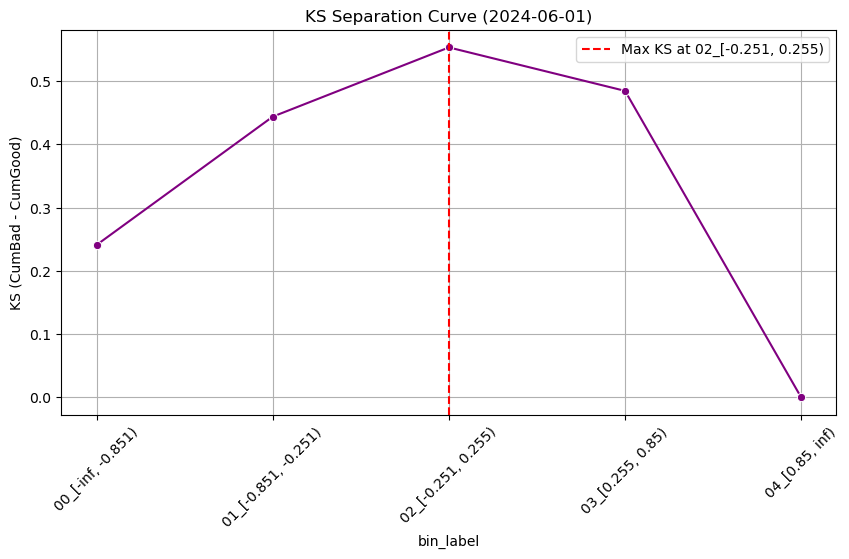

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# 选一个时间切片（比如最近一个月）
last_month = "2024-06-01"
df_last = pl.from_pandas(c).filter(
    (pl.col("feature") == "feature_stable") & 
    (pl.col("_mars_auto_month") == last_month)
).to_pandas()

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_last, x="bin_label", y="ks_bin", marker="o", color="purple")
plt.title(f"KS Separation Curve ({last_month})")
plt.ylabel("KS (CumBad - CumGood)")
plt.xticks(rotation=45)
plt.grid(True)

# 标出最大值点
max_ks = df_last["ks_bin"].max()
max_bin = df_last.loc[df_last["ks_bin"].idxmax(), "bin_label"]
plt.axvline(x=max_bin, color='r', linestyle='--', label=f"Max KS at {max_bin}")
plt.legend()
plt.show()

In [28]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import polars as pl
import numpy as np

def plot_binning_detail(detail_df, group_col, group_value, feature_name):
    """
    使用 detail_table 绘制单张分箱分析图
    """
    # 1. 筛选特定分组的数据
    if isinstance(detail_df, pl.DataFrame):
        plot_data = detail_df.filter(
            (pl.col(group_col) == group_value) & 
            (pl.col("feature") == feature_name)
        ).to_pandas()
    else:
        plot_data = pl.from_pandas(detail_df).filter(
            (pl.col(group_col) == group_value) & 
            (pl.col("feature") == feature_name)
        ).to_pandas()
    
    if plot_data.empty:
        print(f"❌ No data found for group: '{group_value}' in column: '{group_col}'")
        return

    # 2. 准备绘图数据
    labels = plot_data["bin_label"]
    dist = plot_data["N_A"] / plot_data["Total_N"]
    bad_rate = plot_data["bin_bad_rate"]
    lift = plot_data["lift_bin"]
    avg_bad_rate = plot_data["Total_B"].iloc[0] / plot_data["Total_N"].iloc[0]

    # 3. 计算标题所需的聚合指标
    total_iv = plot_data["iv_bin"].sum()
    max_ks = plot_data["ks_bin"].max() * 100 
    
    # 计算 AUC，并强制 >= 0.5
    raw_auc = plot_data["auc_bin"].sum()
    total_auc = max(raw_auc, 1 - raw_auc) 
    
    total_psi = plot_data["psi_bin"].sum()

    # --- 开始绘图 ---
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # A. 绘制柱状图 (分布)
    bars = ax1.bar(labels, dist, color='#d3d3d3', label='Count Dist', alpha=0.7)
    ax1.set_ylabel('Distribution', color='#555')
    ax1.set_ylim(0, dist.max() * 1.6)
    ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    # 【核心修改】将占比文字放在柱子中央
    for bar, pct in zip(bars, dist):
        height = bar.get_height()
        # 只有当高度大于0时才标注，避免文字重叠在X轴
        if height > 0:
            ax1.text(
                x=bar.get_x() + bar.get_width()/2., 
                y=height / 2, # 高度的一半
                s=f'{pct:.1%}', 
                ha='center', va='center', # 垂直居中
                color='black', # 改为黑色以增加对比度
                fontsize=9
            )

    # B. 绘制折线图 (坏账率) - 双Y轴
    ax2 = ax1.twinx()
    ax2.plot(labels, bad_rate, color='#c0392b', linewidth=2, label='Bad Rate')
    ax2.scatter(labels, bad_rate, color='#c0392b', s=50, zorder=5)
    
    ax2.set_ylabel('Bad Rate', color='#c0392b')
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    # 动态调整Y轴范围
    y_max = max(bad_rate.max(), avg_bad_rate)
    ax2.set_ylim(0, y_max * 1.4) 

    # 绘制 Lift 和 BadRate 标签
    for i, (br, lft) in enumerate(zip(bad_rate, lift)):
        # 1. 上方显示 Lift (黑色/大字体/粗体)
        lift_text = f"{lft:.2f}" if np.isfinite(lft) else "-"
        
        ax2.annotate(
            text=f"{lift_text}", 
            xy=(i, br), 
            xytext=(0, 8), textcoords='offset points', # 向上偏移
            ha='center', va='bottom', 
            color='black', fontweight='bold', fontsize=10
        )

        # 2. 下方显示 Bad Rate (红色/小字体/正常粗细)
        ax2.annotate(
            text=f"{br:.1%}", 
            xy=(i, br), 
            xytext=(0, -8), textcoords='offset points', # 向下偏移
            ha='center', va='top', 
            color='#c0392b', fontweight='normal', fontsize=9
        )

    # C. 绘制平均坏账率虚线
    ax2.axhline(y=avg_bad_rate, color='gray', linestyle='--', alpha=0.7, label='Avg Bad Rate')

    # D. 设置标题
    title_str = (f"[{feature_name}] Group: {group_value}\n"
                 f"IV: {total_iv:.3f} | KS: {max_ks:.1f} | AUC: {total_auc:.3f} | PSI: {total_psi:.3f}")
    plt.title(title_str, fontsize=12, pad=20)
    
    ax1.set_xticklabels(labels, rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

C:\Users\67177\AppData\Local\Temp\ipykernel_40512\3906904522.py:108: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



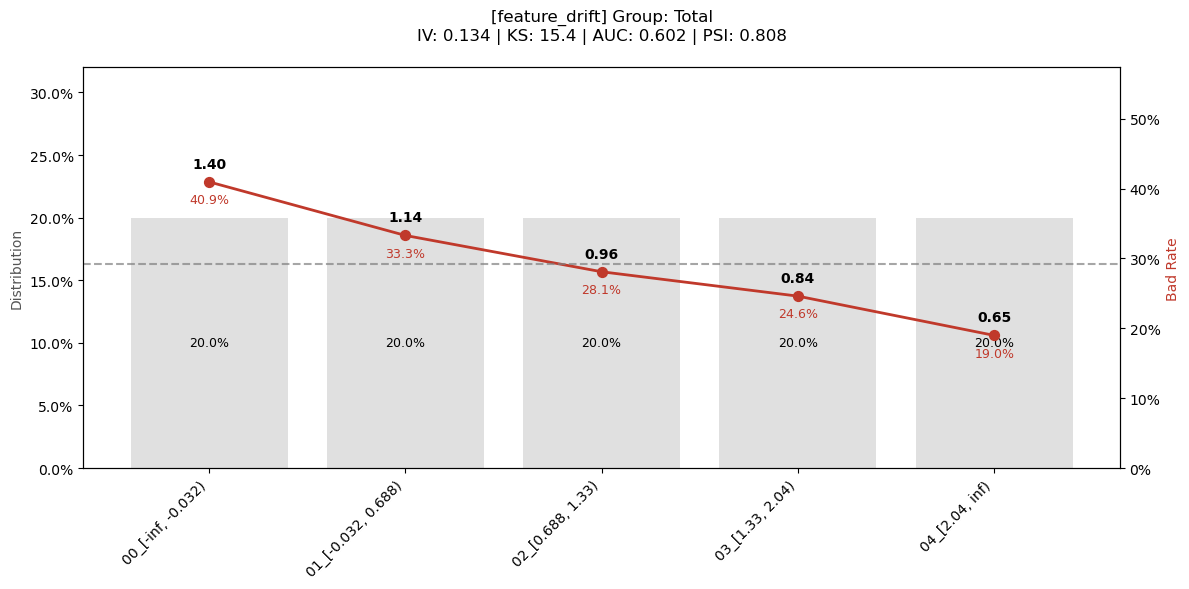

C:\Users\67177\AppData\Local\Temp\ipykernel_40512\3906904522.py:108: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



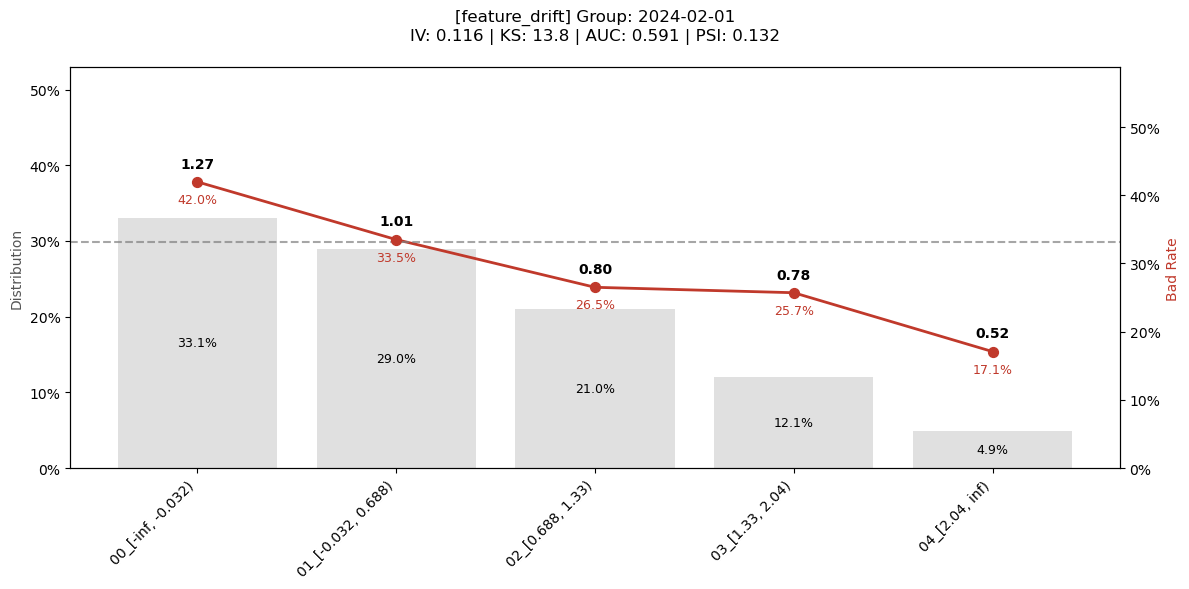

In [29]:
# 获取长表
summary_df, trend_tables, detail_df = report.get_data()

# 确定你的分组列名 (如果你用了自动日期聚合，通常是 _mars_auto_month)
# 如果你没有用自动聚合，那就是你传的 profile_by (例如 'month')
my_group_col = "_mars_auto_month" 

# 1. 画全量 (Total)
plot_binning_detail(
    detail_df, 
    group_col=my_group_col, 
    group_value="Total", 
    feature_name="feature_drift"
)

# 2. 画特定月份 (注意：如果长表里存的是 String 格式的日期，要传 String)
# 可以先看一下长表里的值长什么样：print(detail_df[my_group_col].unique())
plot_binning_detail(
    detail_df, 
    group_col=my_group_col, 
    group_value="2024-02-01", 
    feature_name="feature_drift"
)